# Notebook for reading result CSV files

In [3]:
import os
import pandas as pd
from collections import defaultdict

TOP_FOLDER = "results_hashed/bucket_evaluation"
INCLUDED_FOLDERS = {"loose", "original"}  # Only check inside these, and the root

all_csv_files = []

# 1. Recursively find CSV files that contain "disk" and are inside bucket_evaluation or subfolders "loose" or "original"
for root, dirs, files in os.walk(TOP_FOLDER):
    # Check if we're in bucket_evaluation, loose, or original
    relative_root = os.path.relpath(root, TOP_FOLDER)
    top_level_dir = relative_root.split(os.sep)[0] if relative_root != "." else ""
    if top_level_dir not in INCLUDED_FOLDERS and relative_root != ".":
        continue

    for filename in files:
        if filename.lower().endswith(".csv") and "grid" in filename.lower():
            full_path = os.path.join(root, filename)
            all_csv_files.append(full_path)

# 2. Group CSVs by their *relative* folder under TOP_FOLDER
csv_by_folder = defaultdict(list)
for csv_path in all_csv_files:
    relative_path = os.path.relpath(csv_path, TOP_FOLDER)
    folder_path = os.path.dirname(relative_path)
    csv_by_folder[folder_path].append(csv_path)

# 3. Print the CSV files neatly by folder, enumerating them so we can pick by number
print(f"Found the following CSV files under '{TOP_FOLDER}' (containing 'grid' in the filename):\n")

file_index_map = {}  # Maps an integer index => full file path
index_counter = 0

for folder, files in csv_by_folder.items():
    print(f"[Folder] {folder or '(top)'}")
    for f in files:
        print(f"  {index_counter}: {os.path.basename(f)}")
        file_index_map[index_counter] = f
        index_counter += 1
    print()


Found the following CSV files under 'results_hashed/bucket_evaluation' (containing 'grid' in the filename):

[Folder] loose
  0: porto_dtw_grid_500.csv
  1: rome_dtw_grid_500.csv
  2: porto_frechet_grid_300.csv
  3: rome_frechet_grid_300.csv

[Folder] original
  4: porto_dtw_grid_500_original.csv
  5: porto_frechet_grid_300_original.csv
  6: rome_dtw_grid_500_original.csv
  7: rome_frechet_grid_300_original.csv



In [4]:
# 4. Ask user which file to open
choice = input("Enter the number of the CSV file you want to open: ")

# Basic validation in case user types something invalid
try:
    choice_index = int(choice)
    if 0 <= choice_index < len(all_csv_files):
        # 5. Read and display the chosen CSV
        chosen_file = all_csv_files[choice_index]
        print(f"\nOpening: {chosen_file}\n")
        df = pd.read_csv(chosen_file)
        display(df)  # or just print(df) if you like
    else:
        print("Invalid choice index.")
except ValueError:
    print("Please enter an integer number for your choice.")


Opening: results_hashed/bucket_evaluation/original/porto_dtw_grid_500_original.csv



,City,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Total Buckets,Avg Largest Bucket Size,Avg Smallest Bucket Size,Avg Buckets with >1 Trajectory,Avg Buckets with 1 Trajectory,Avg Percentage >1 Trajectory,Avg Percentage 1 Trajectory,Avg Correlation Coefficient
0,porto,dtw,0.1,1,500,0.1,0.042,0.000,0.000,499.958,1.042,1.0,0.042,499.917,0.008,99.992,NaN
1,porto,dtw,0.1,1,500,0.2,0.042,0.000,0.000,499.958,1.042,1.0,0.042,499.917,0.008,99.992,NaN
2,porto,dtw,0.1,1,500,0.3,0.042,0.000,0.000,499.958,1.042,1.0,0.042,499.917,0.008,99.992,NaN
3,porto,dtw,0.1,1,500,0.4,0.042,0.000,0.000,499.958,1.042,1.0,0.042,499.917,0.008,99.992,NaN
4,porto,dtw,0.1,1,500,0.5,0.042,0.000,0.000,499.958,1.042,1.0,0.042,499.917,0.008,99.992,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,porto,dtw,3.0,6,500,0.1,0.006,1.000,0.012,59.167,420.750,1.0,48.458,10.708,81.960,18.040,0.232
896,porto,dtw,3.0,6,500,0.2,0.022,0.999,0.043,59.167,420.750,1.0,48.458,10.708,81.960,18.040,0.232
897,porto,dtw,3.0,6,500,0.3,0.053,0.998,0.100,59.167,420.750,1.0,48.458,10.708,81.960,18.040,0.232
898,porto,dtw,3.0,6,500,0.4,0.100,0.994,0.181,59.167,420.750,1.0,48.458,10.708,81.960,18.040,0.232


# Visualisering av Grid scheme resultater

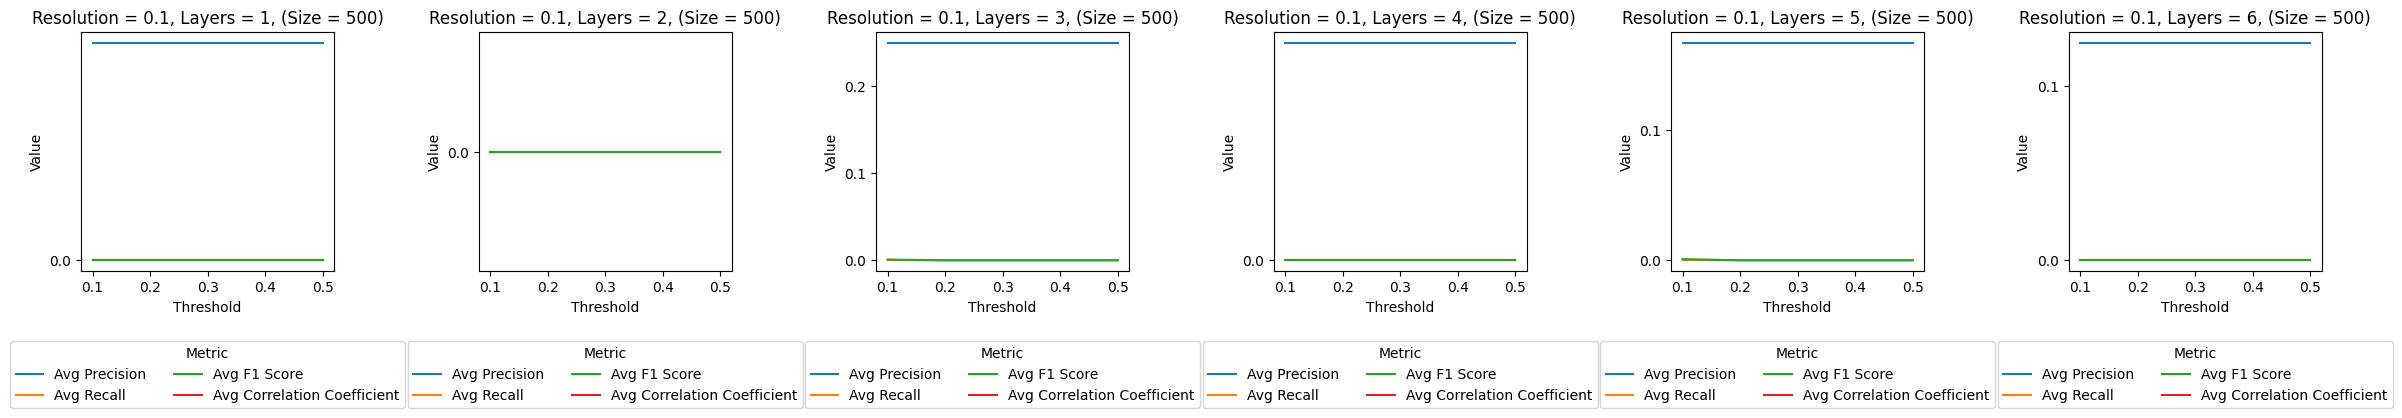

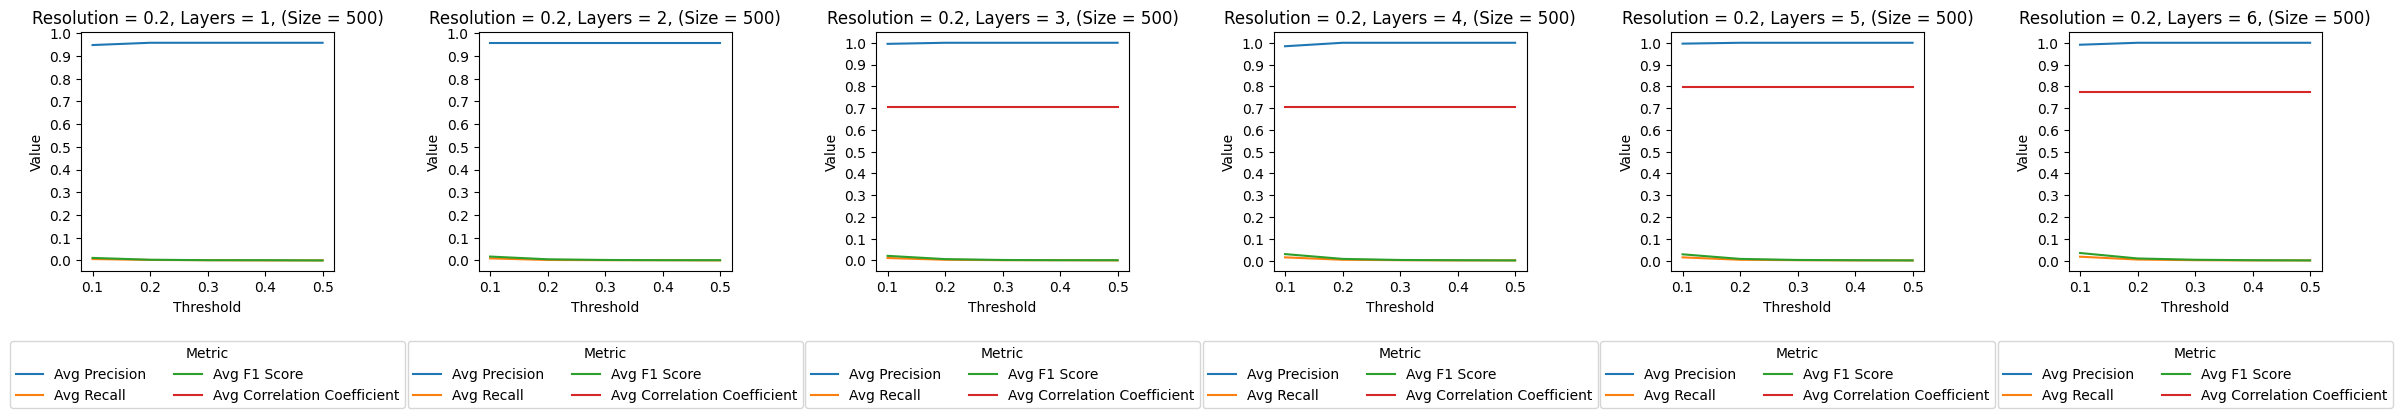

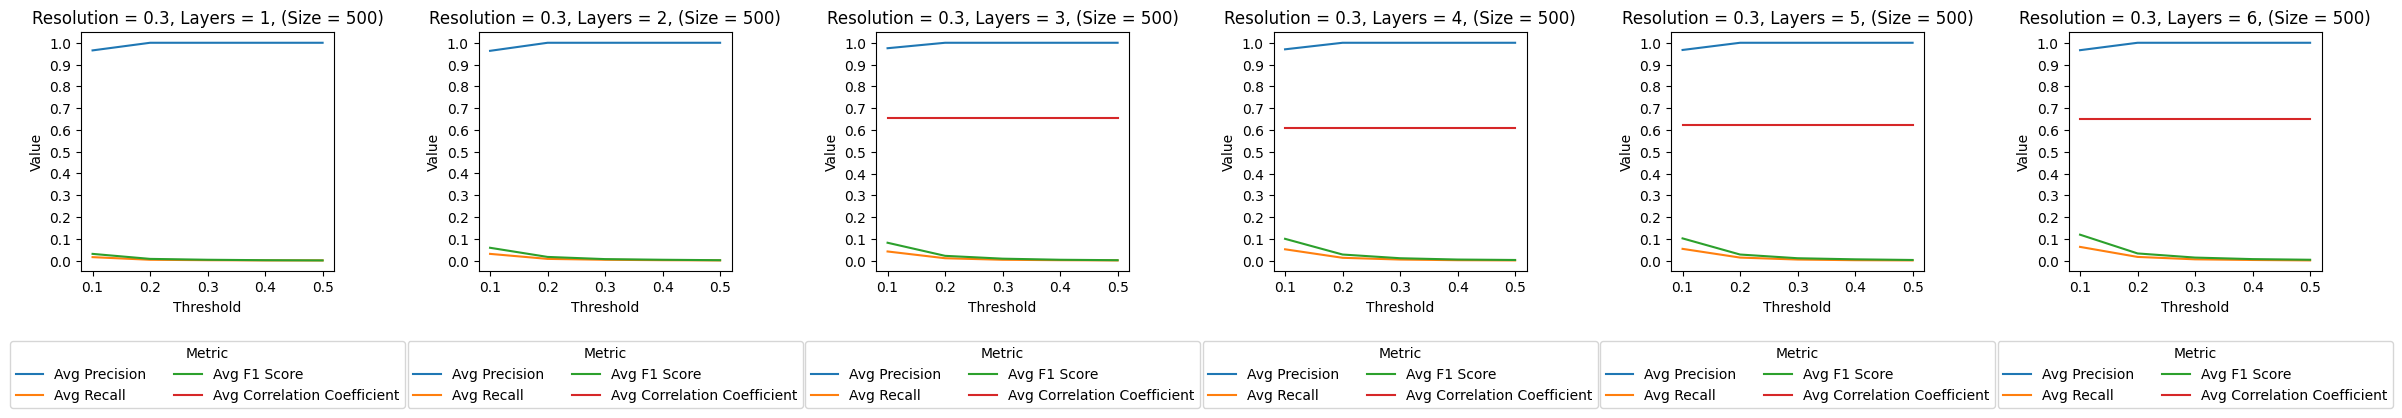

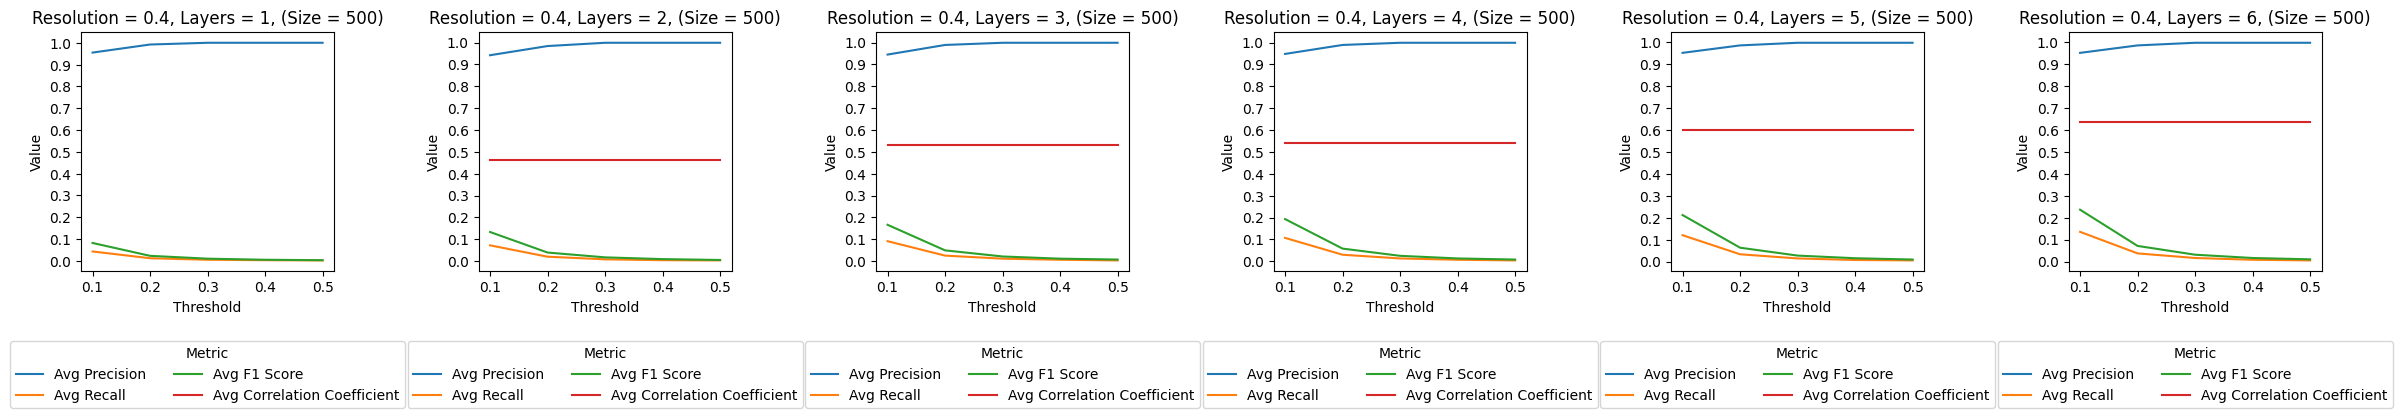

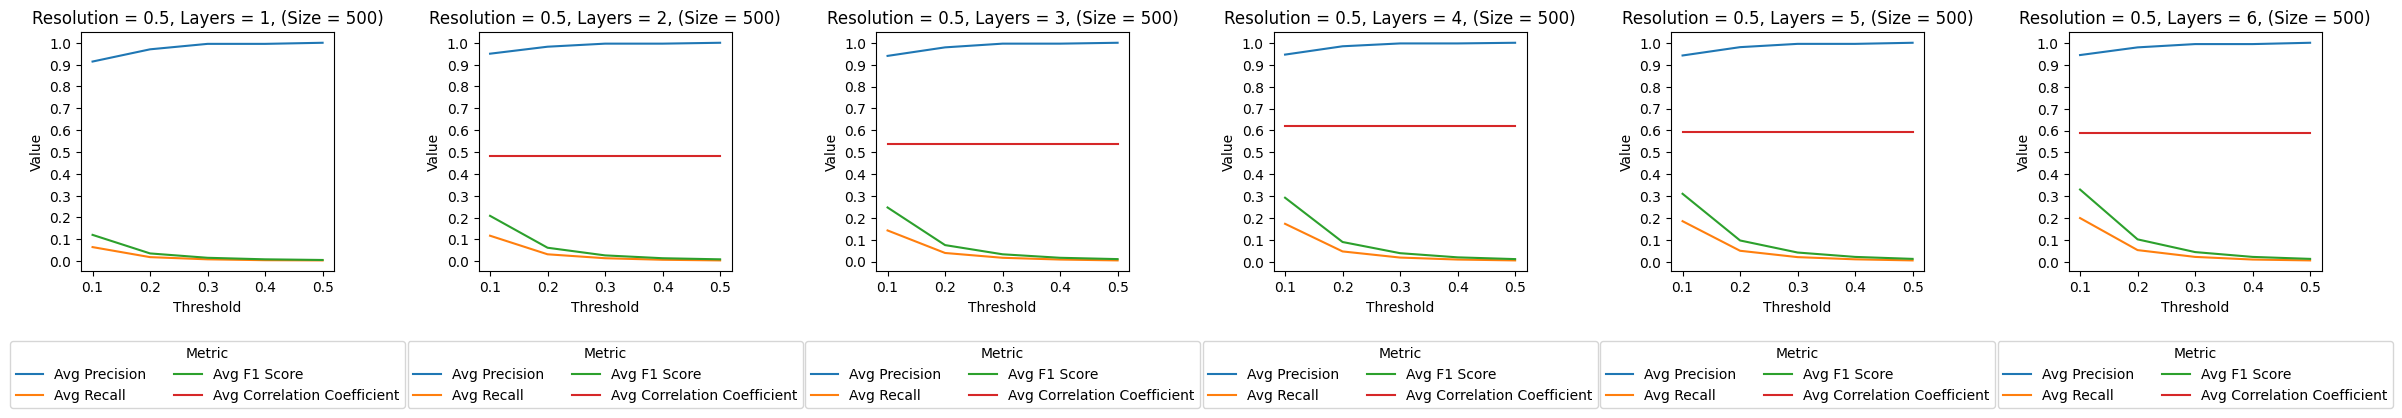

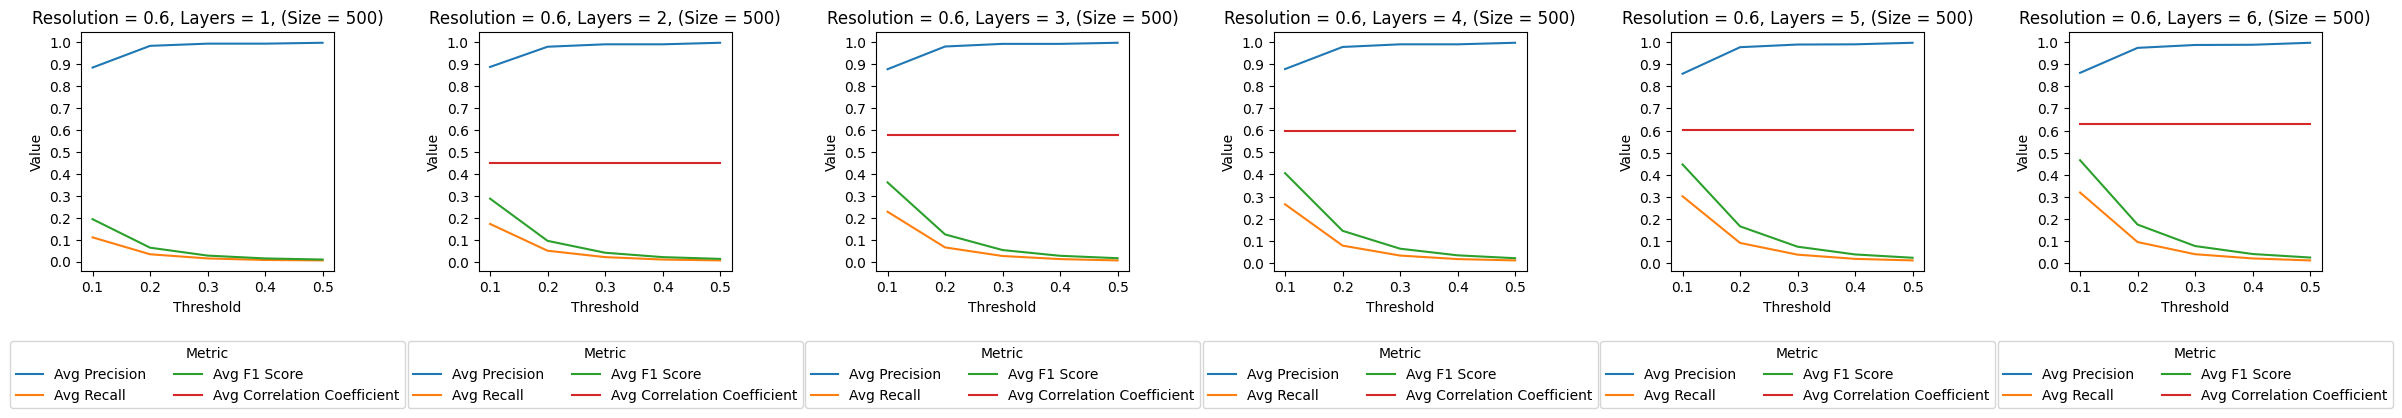

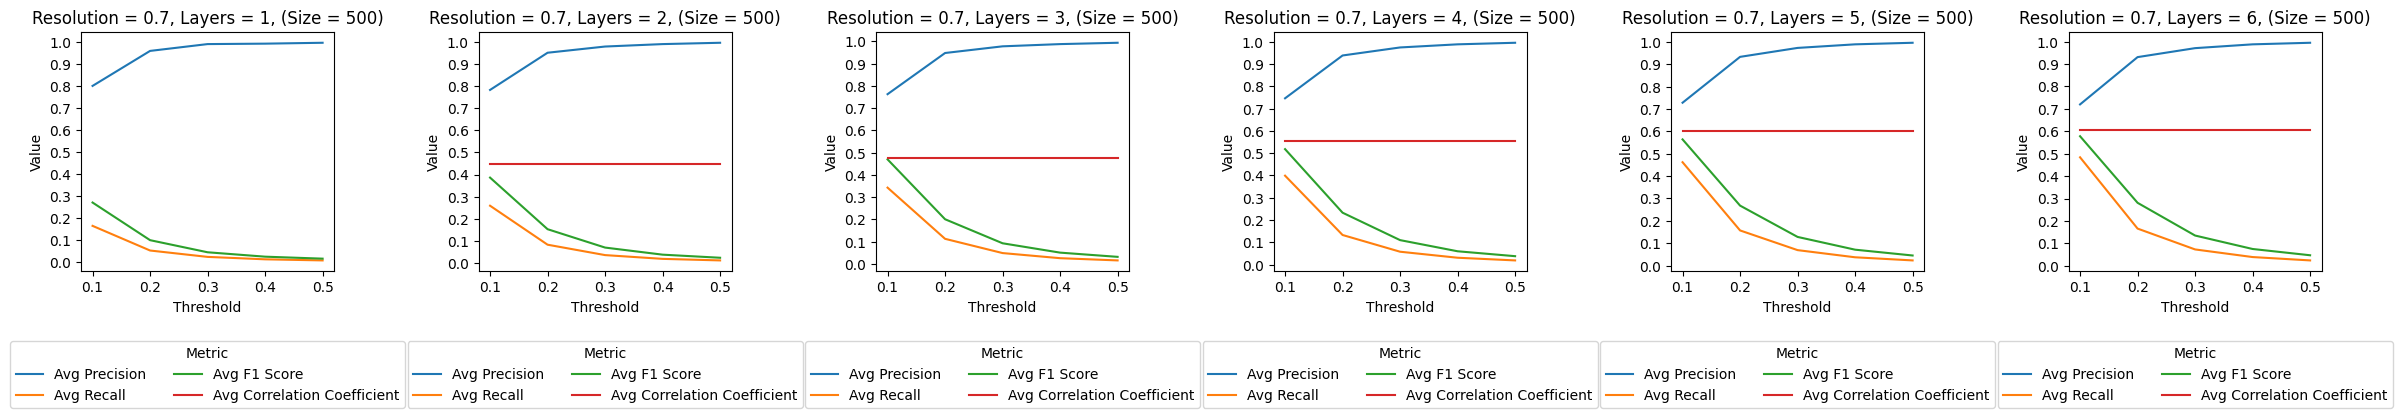

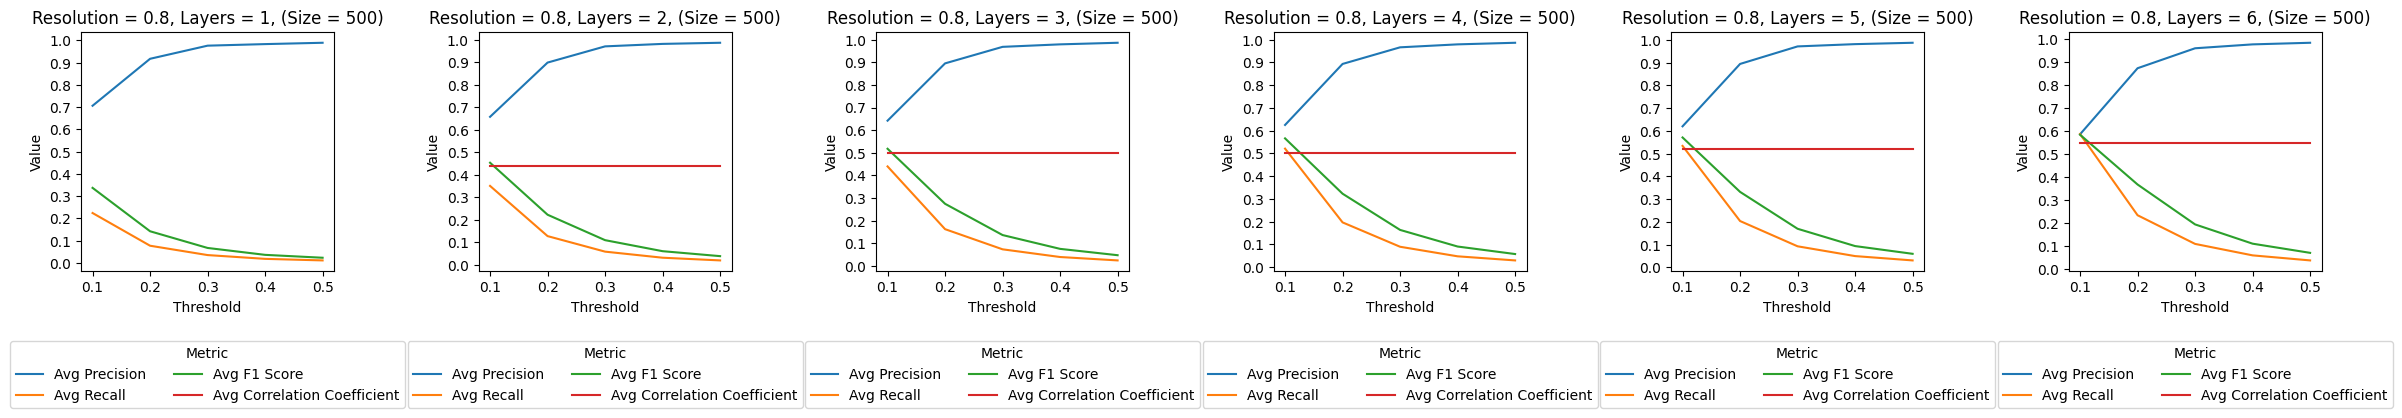

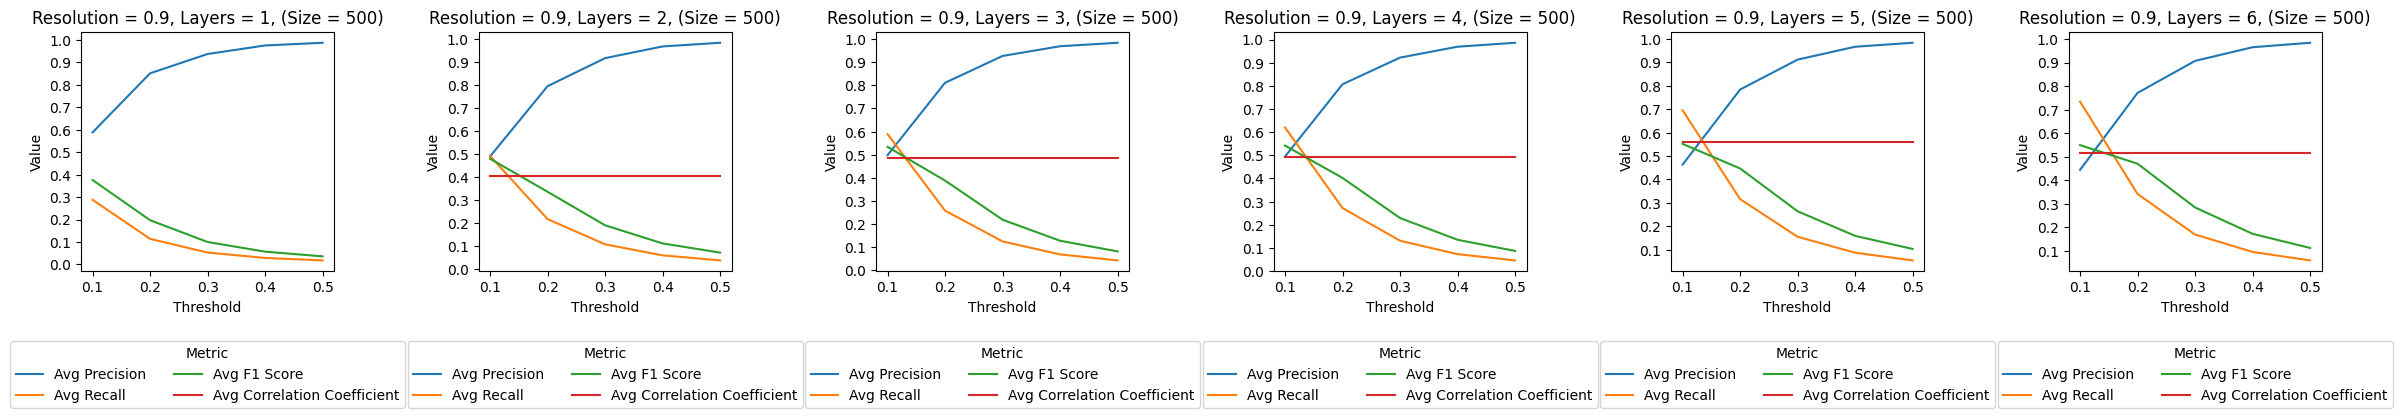

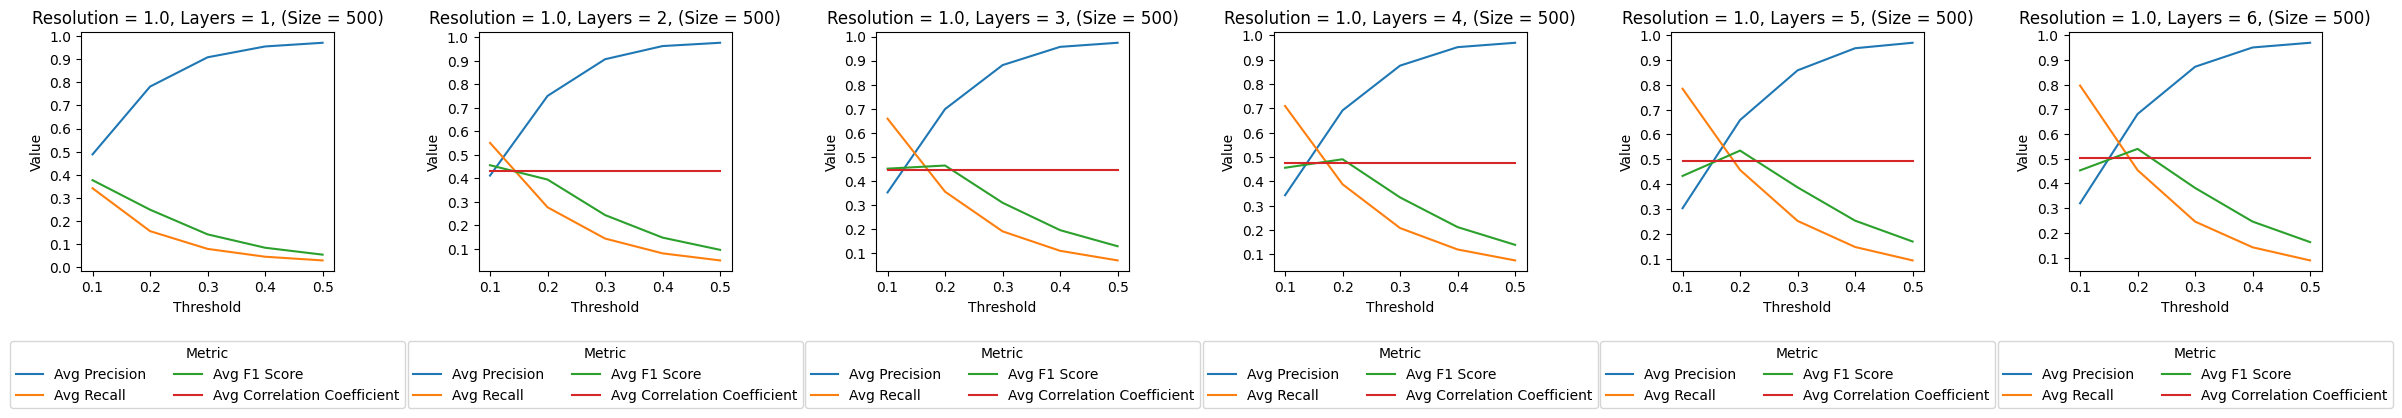

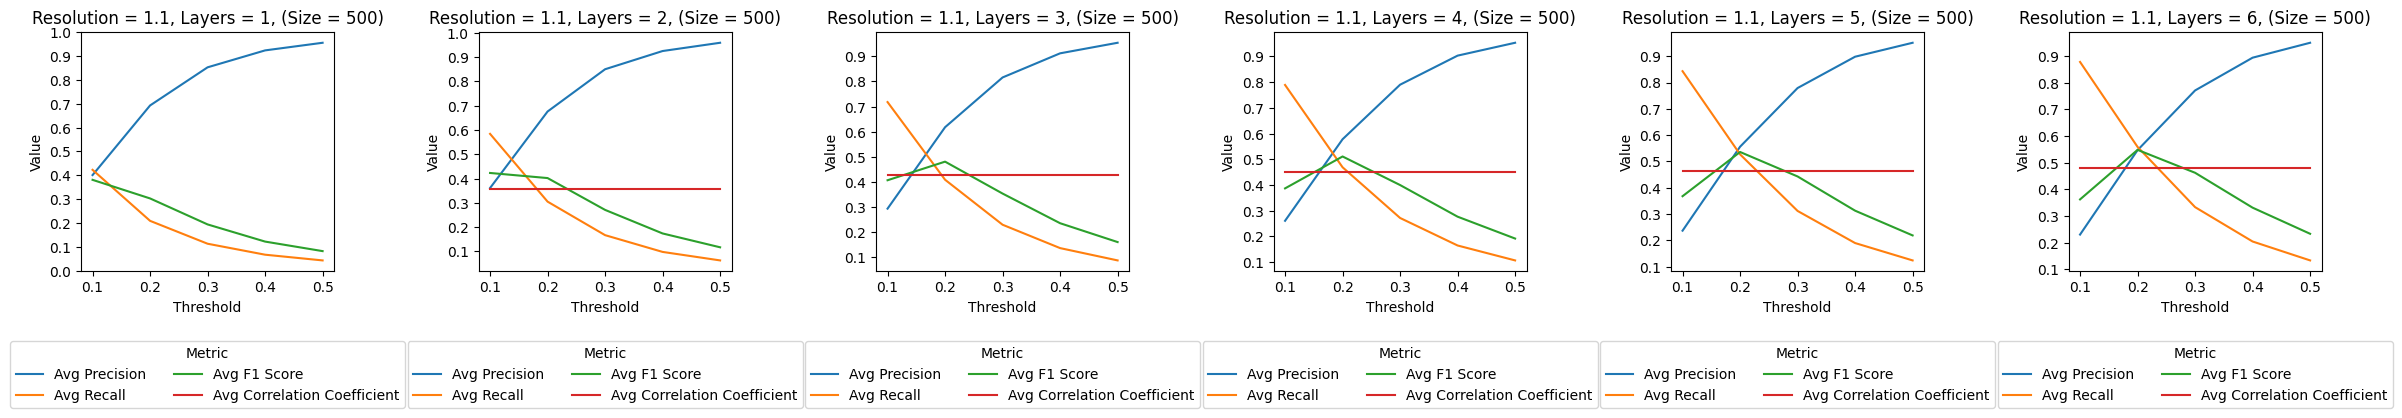

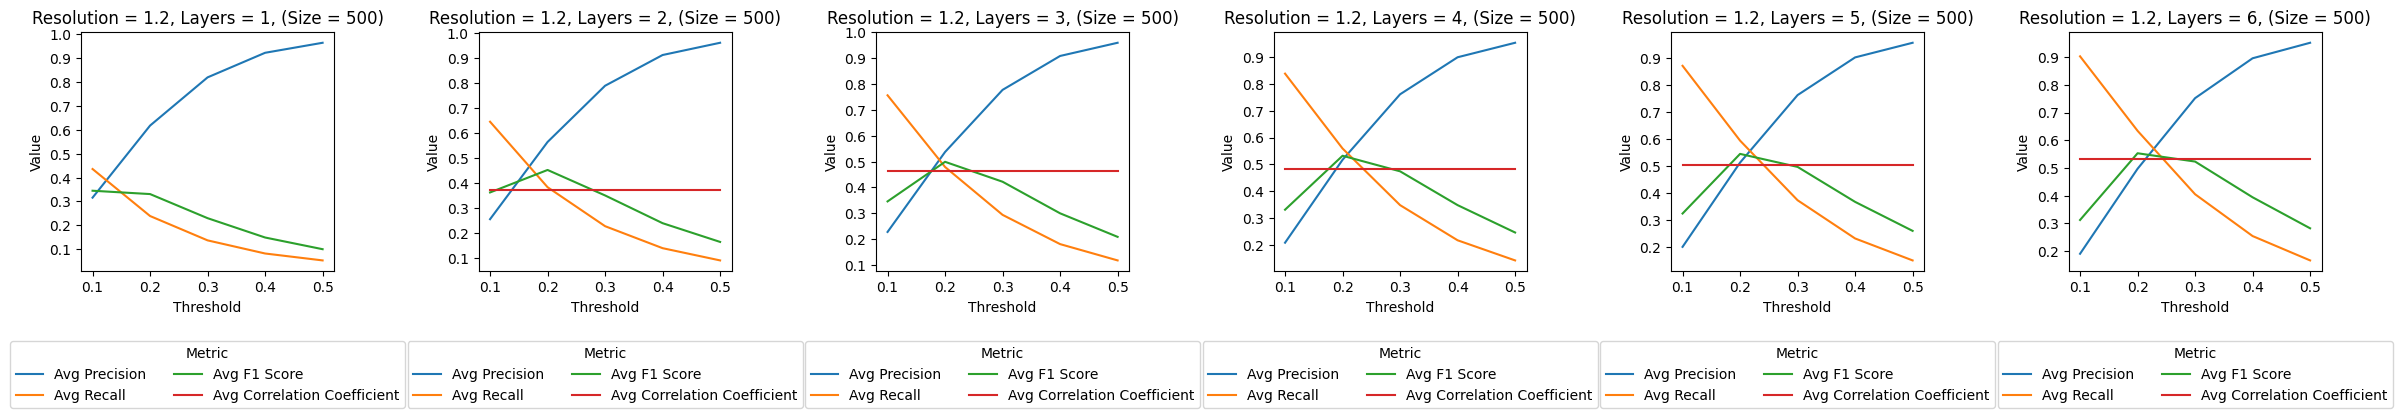

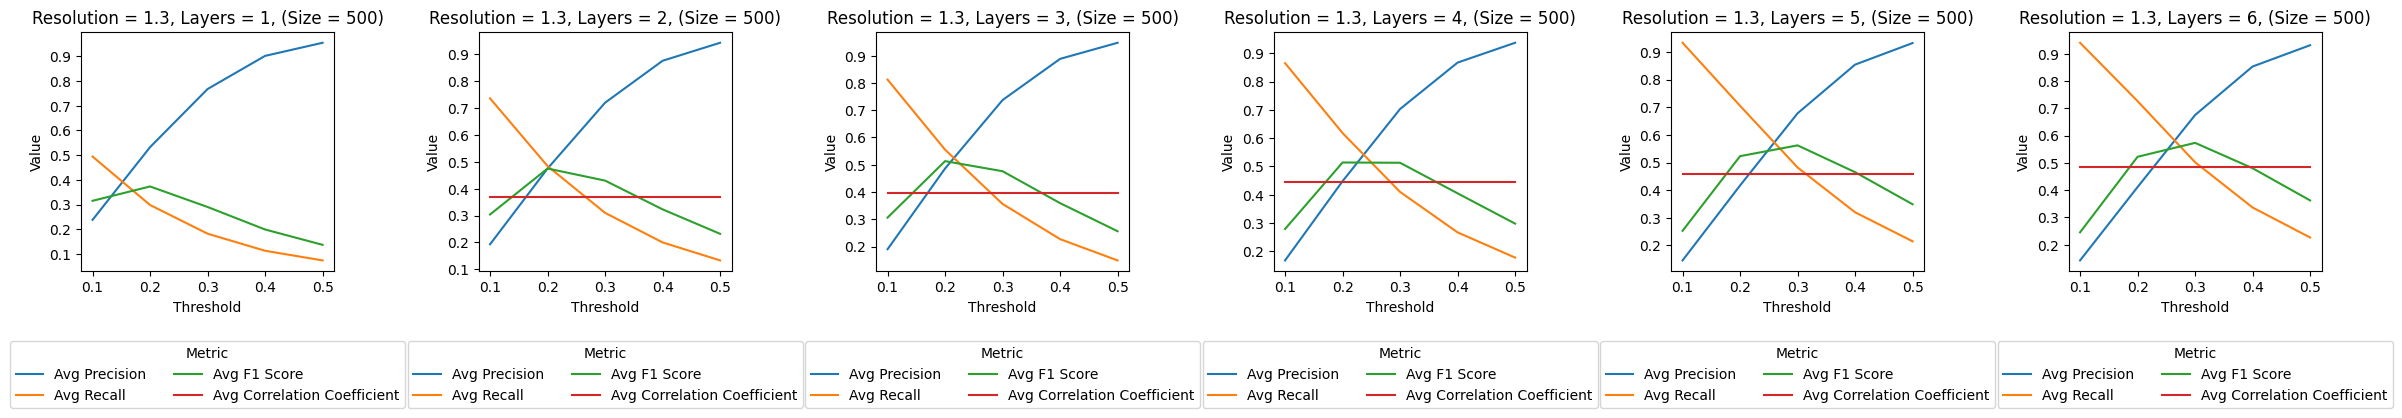

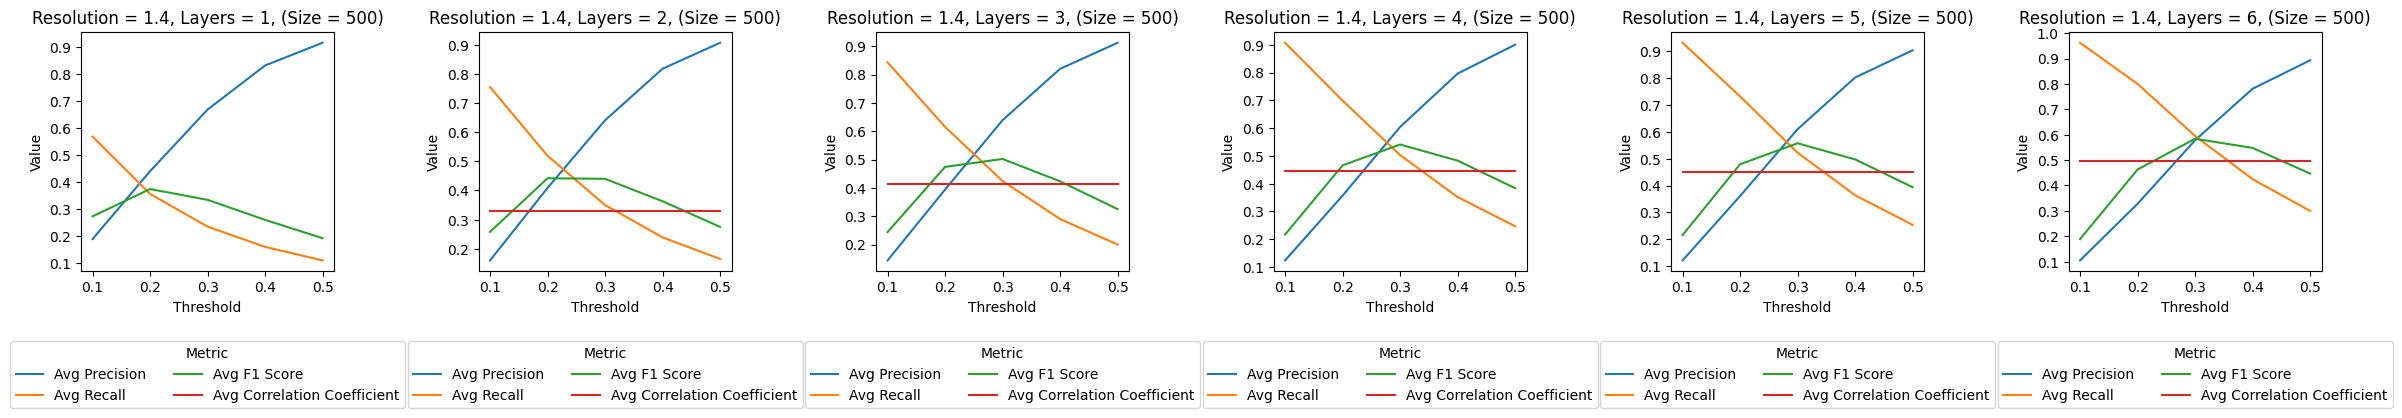

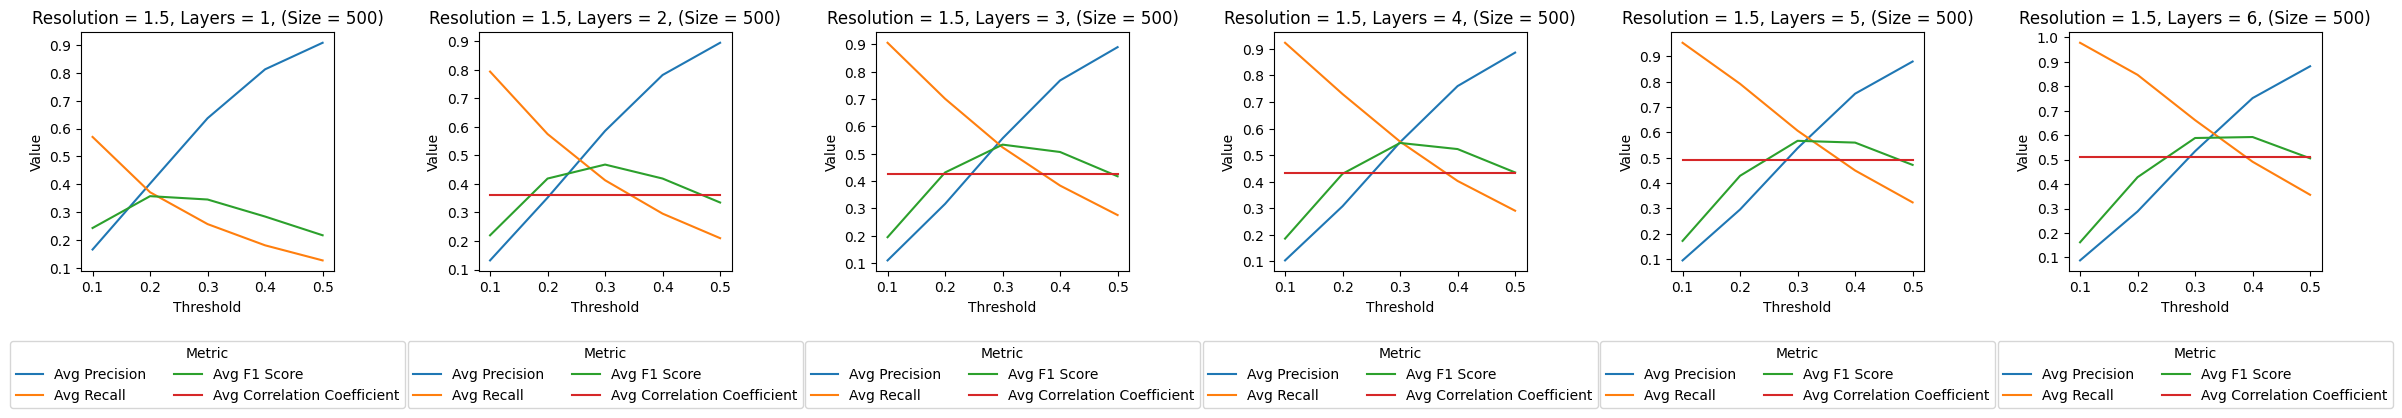

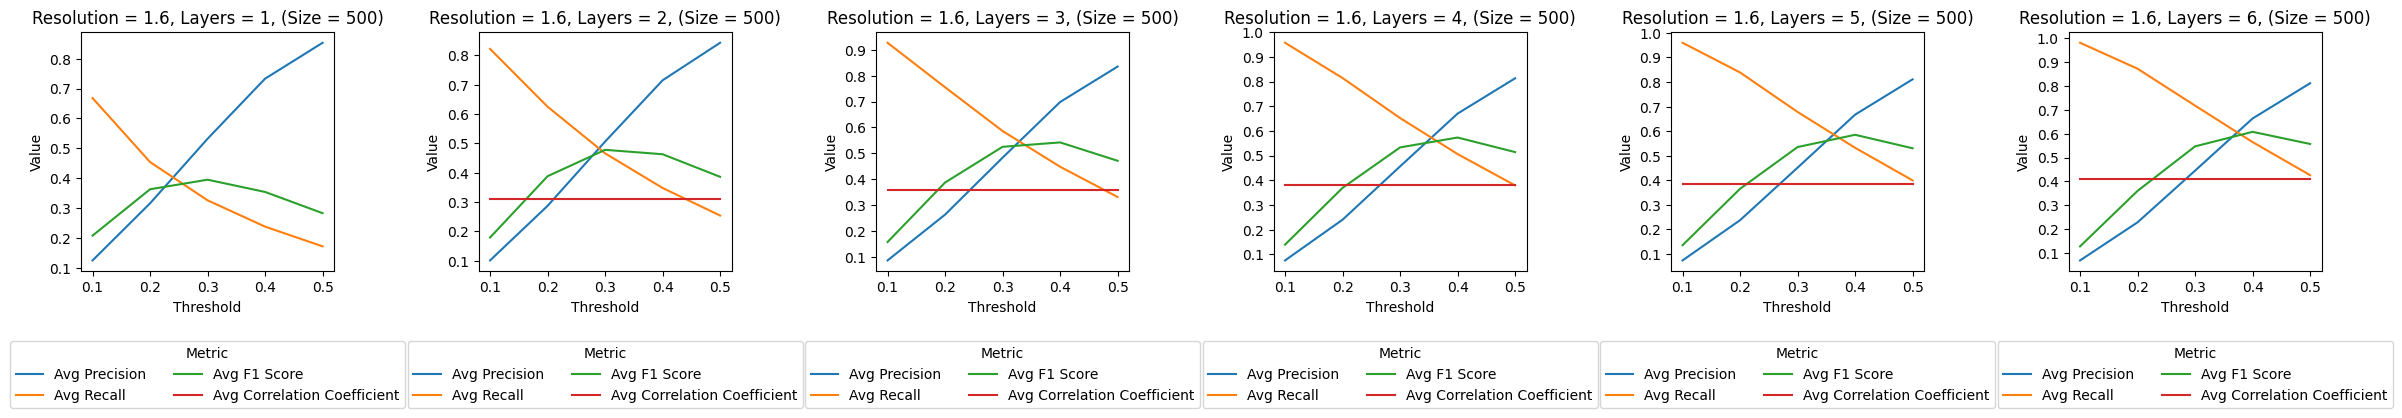

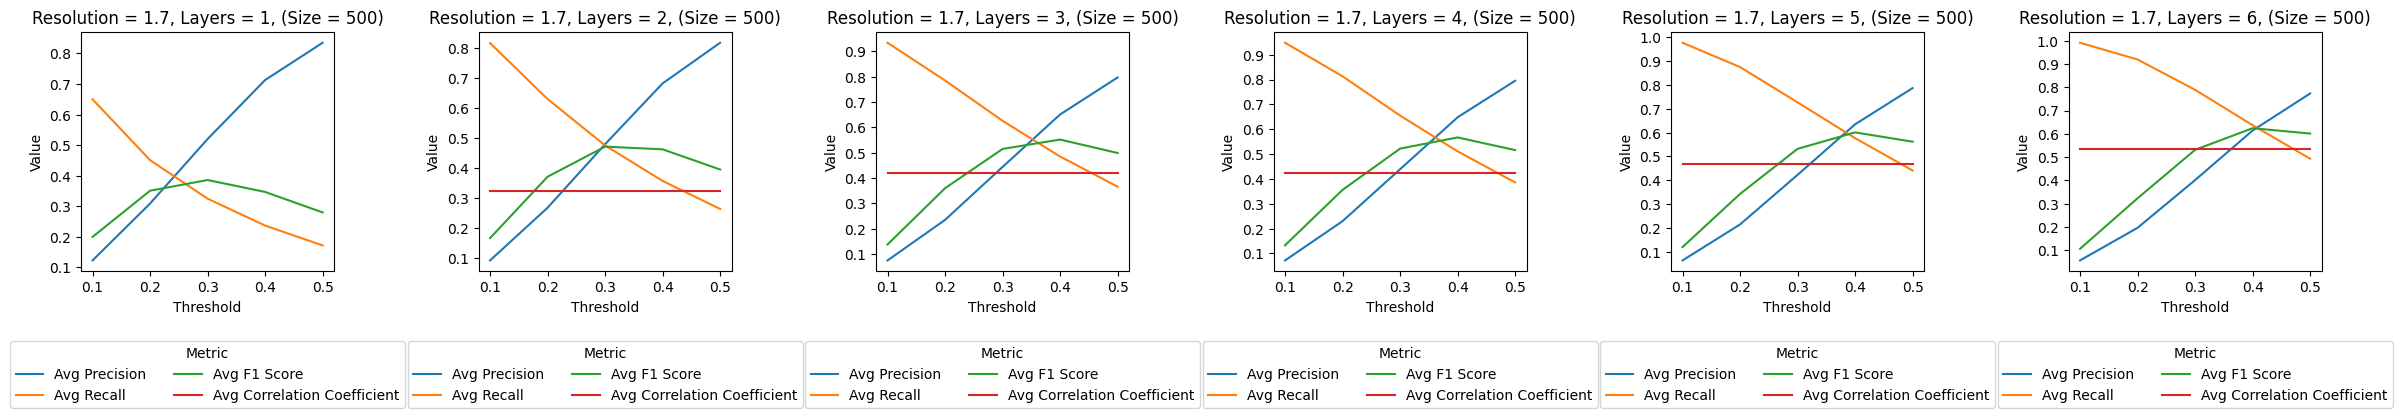

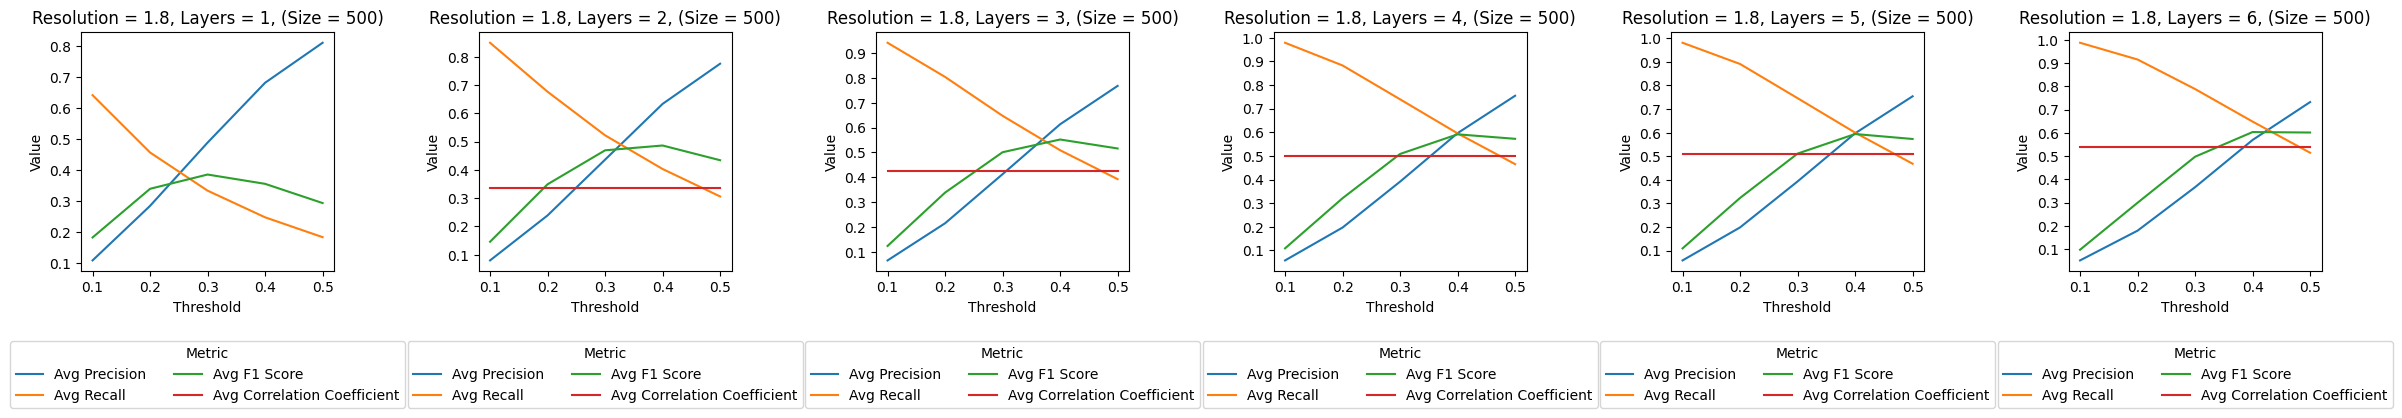

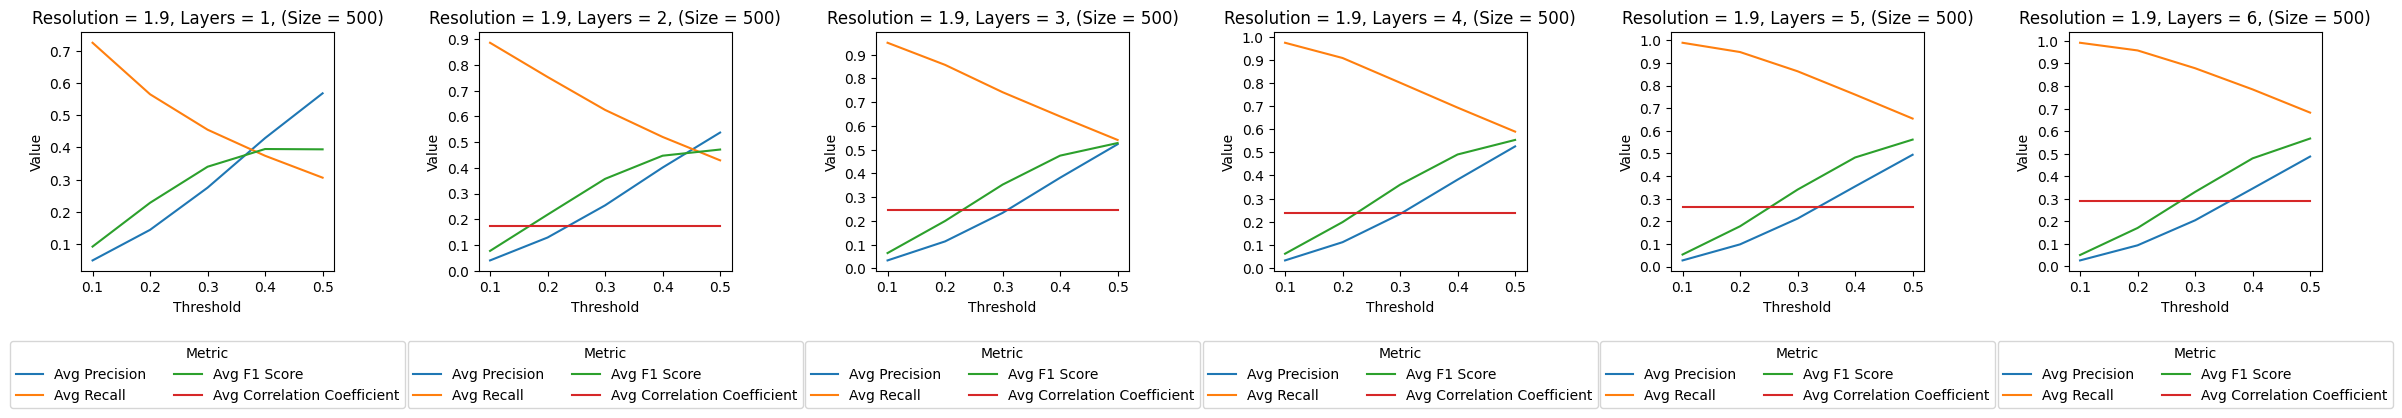

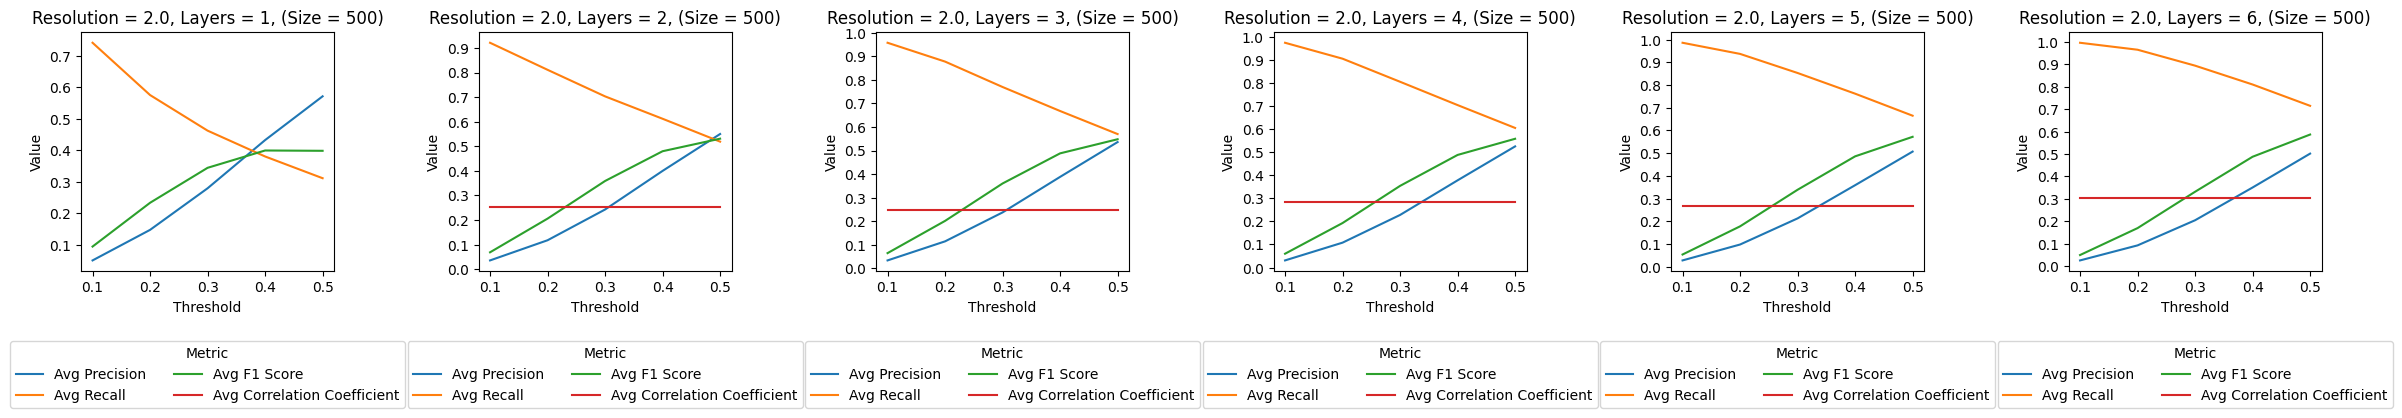

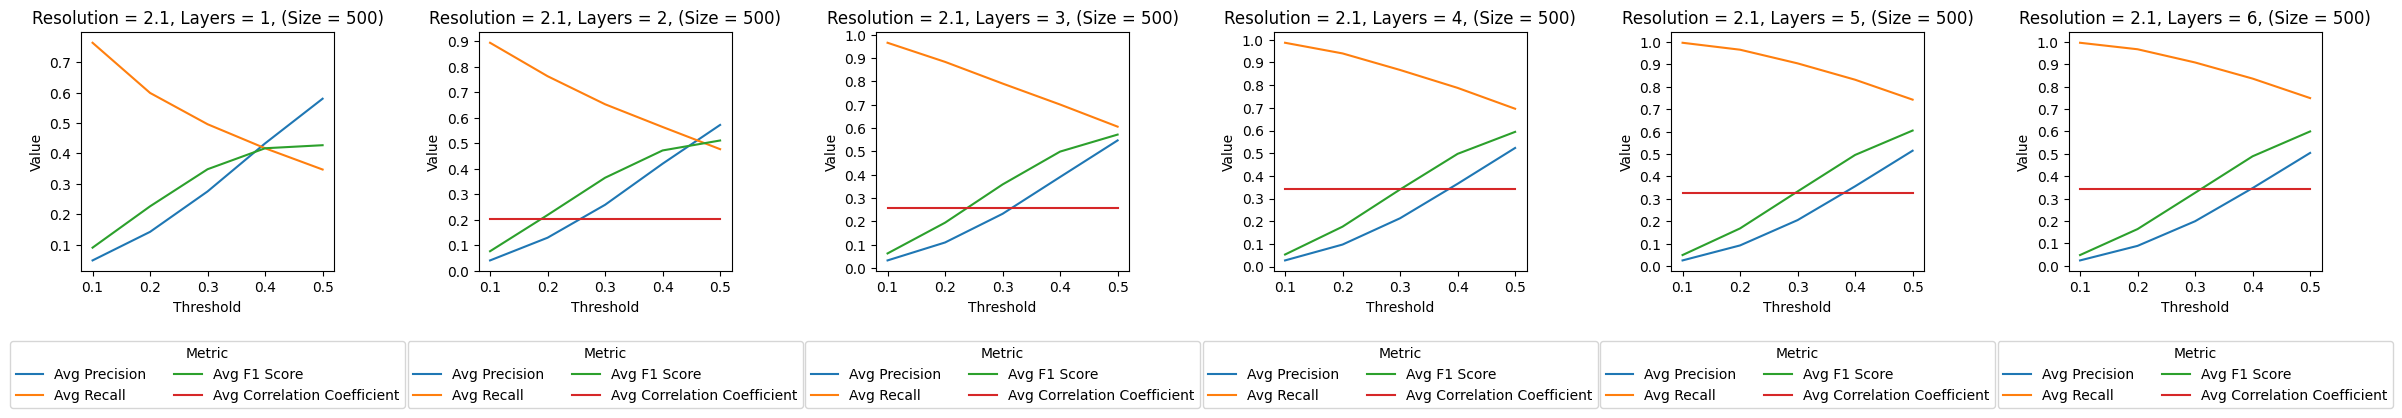

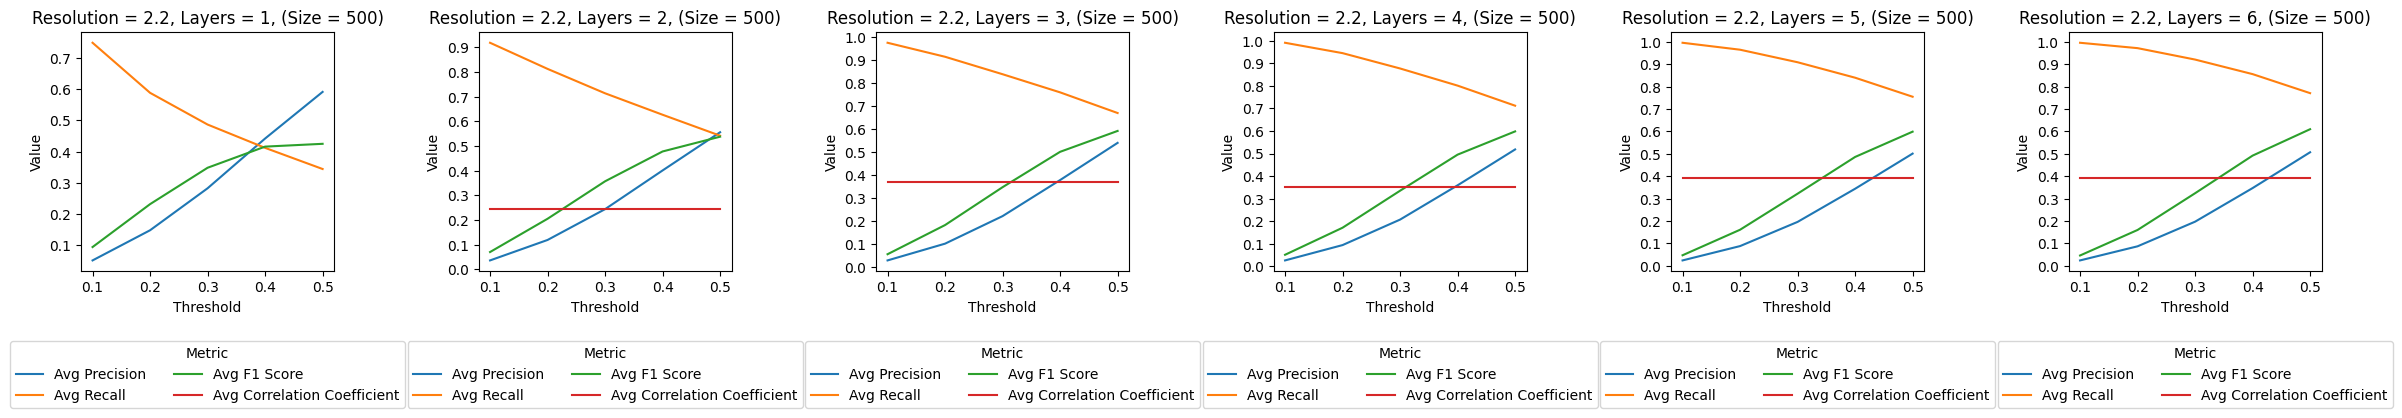

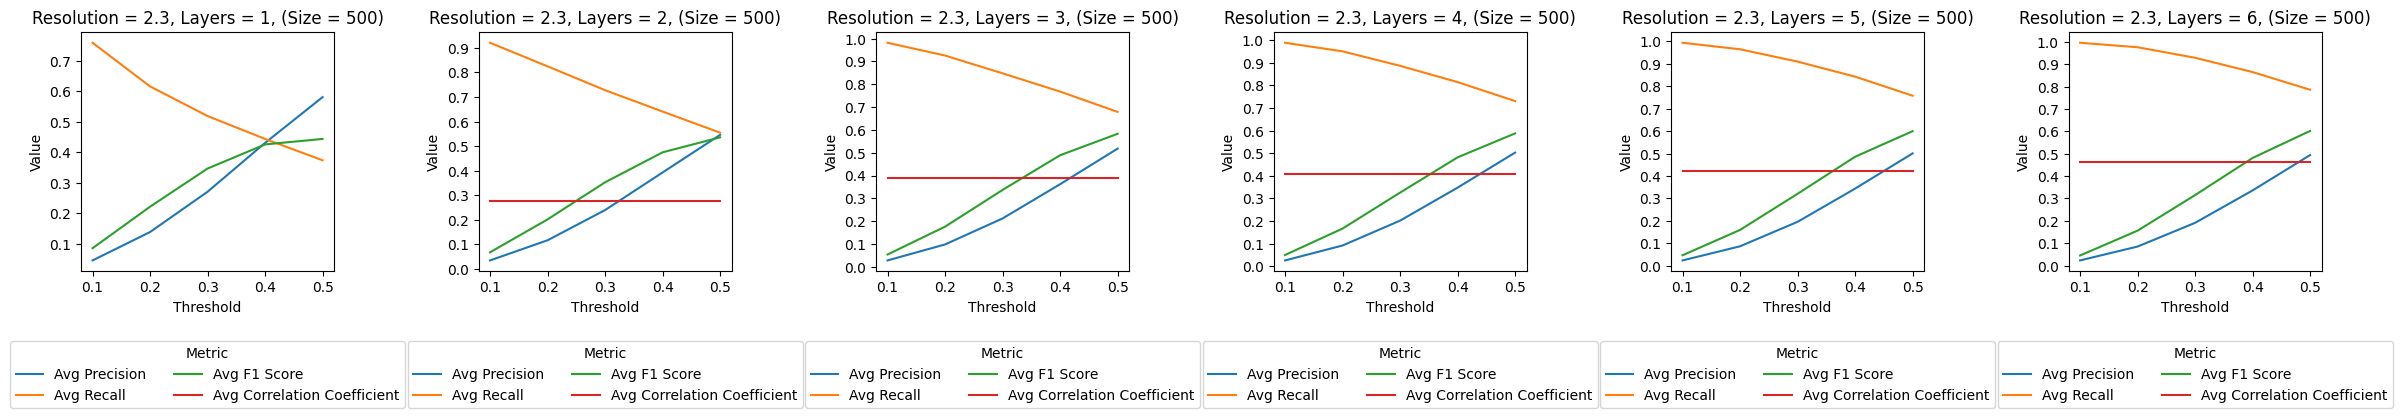

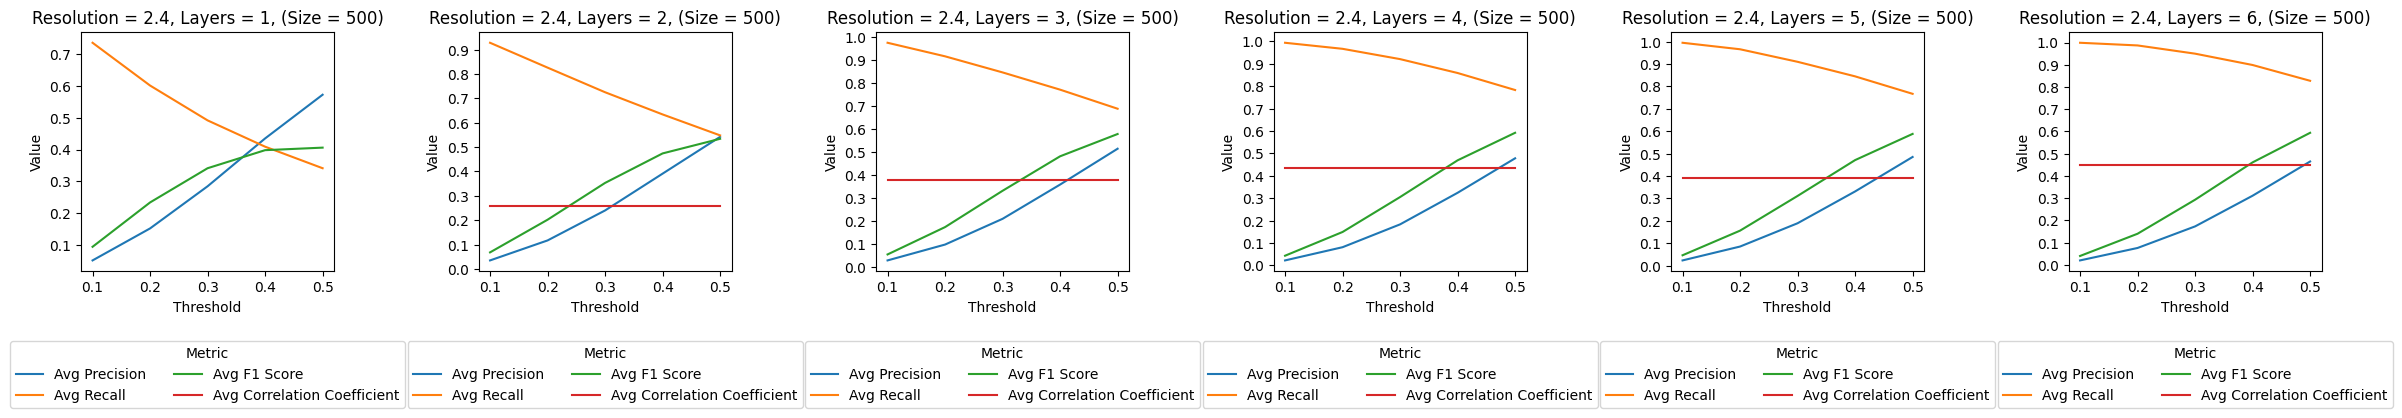

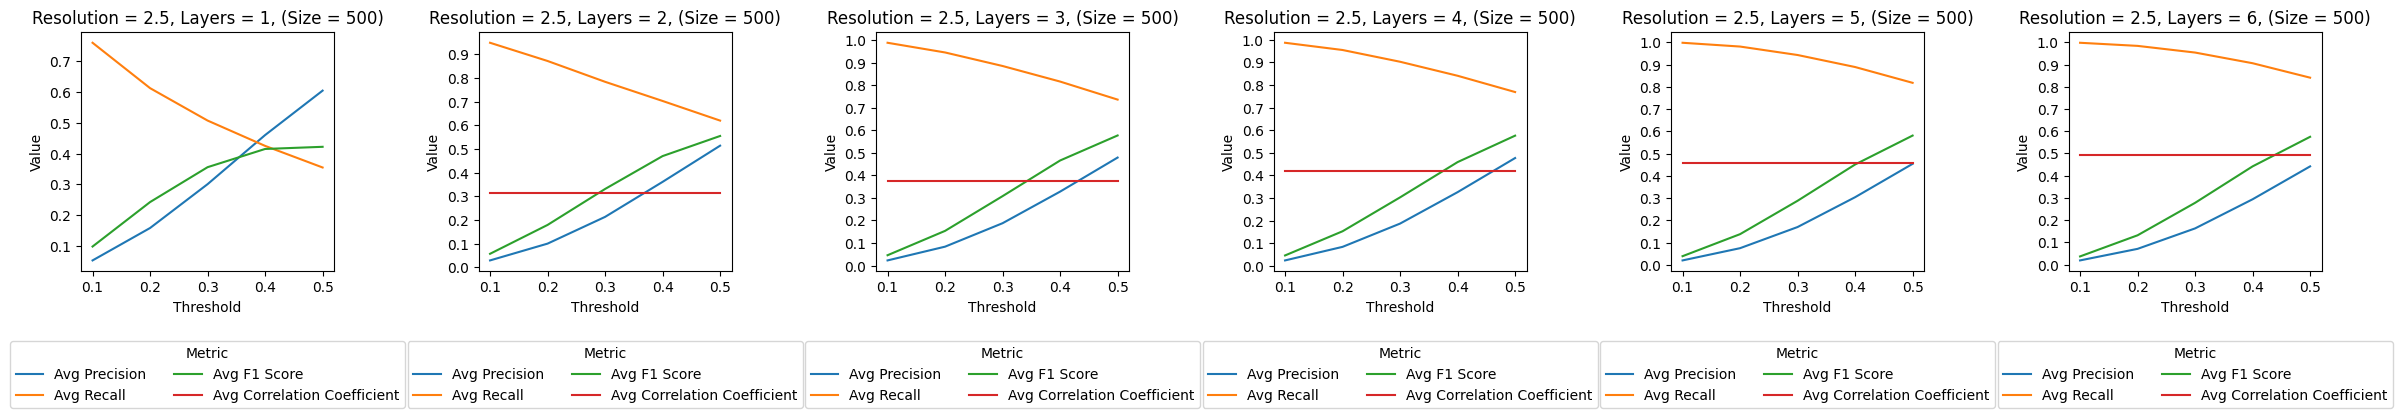

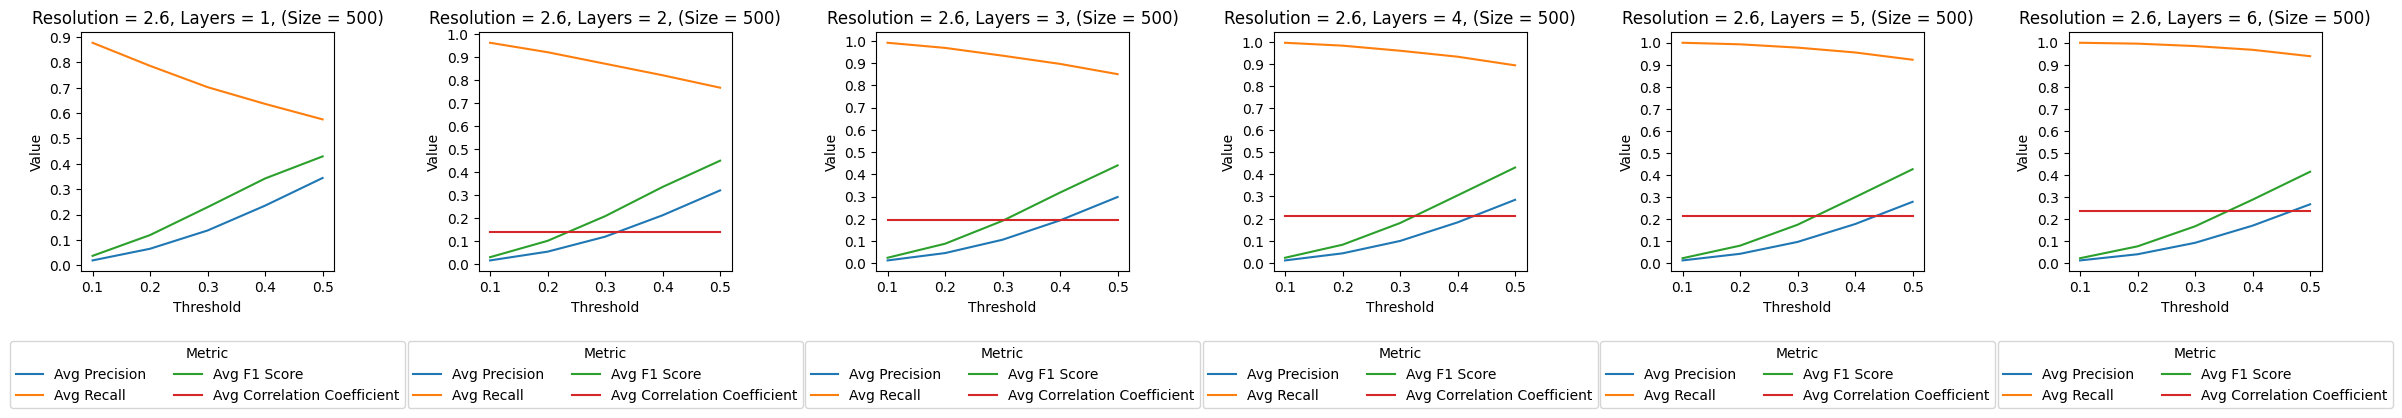

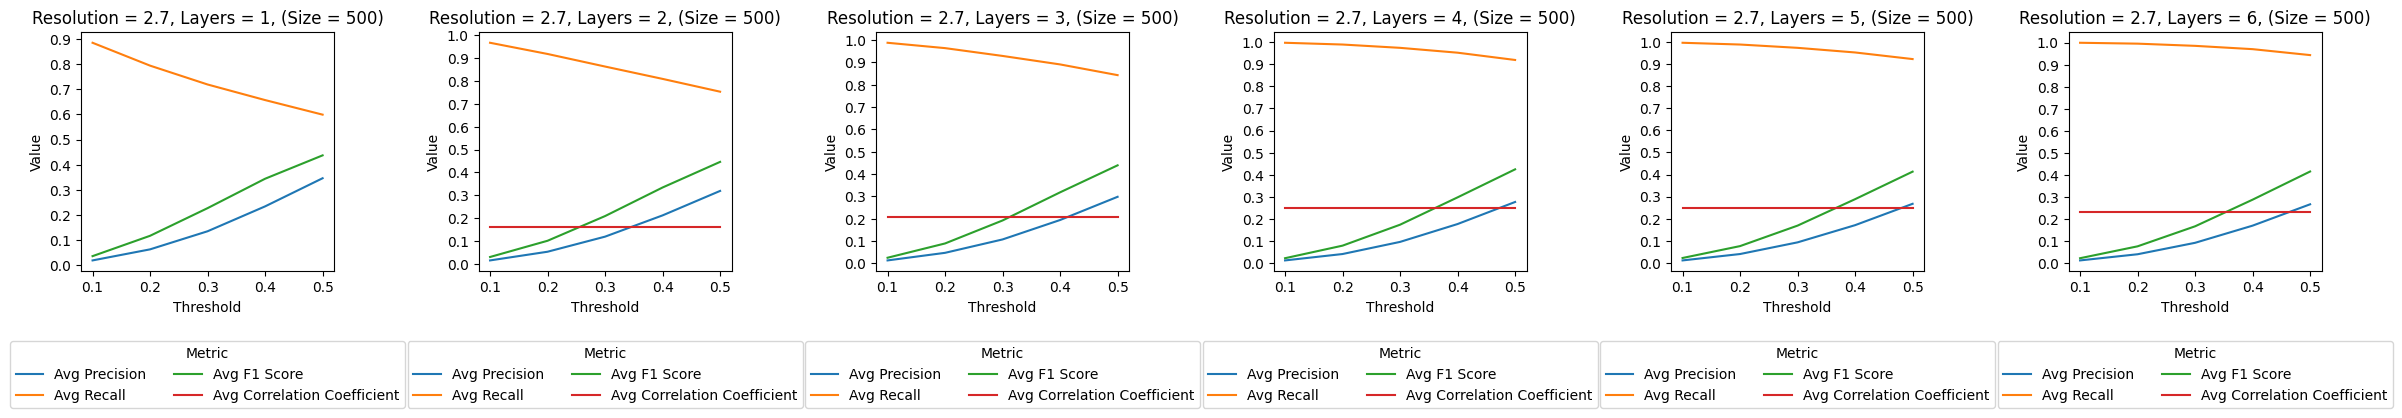

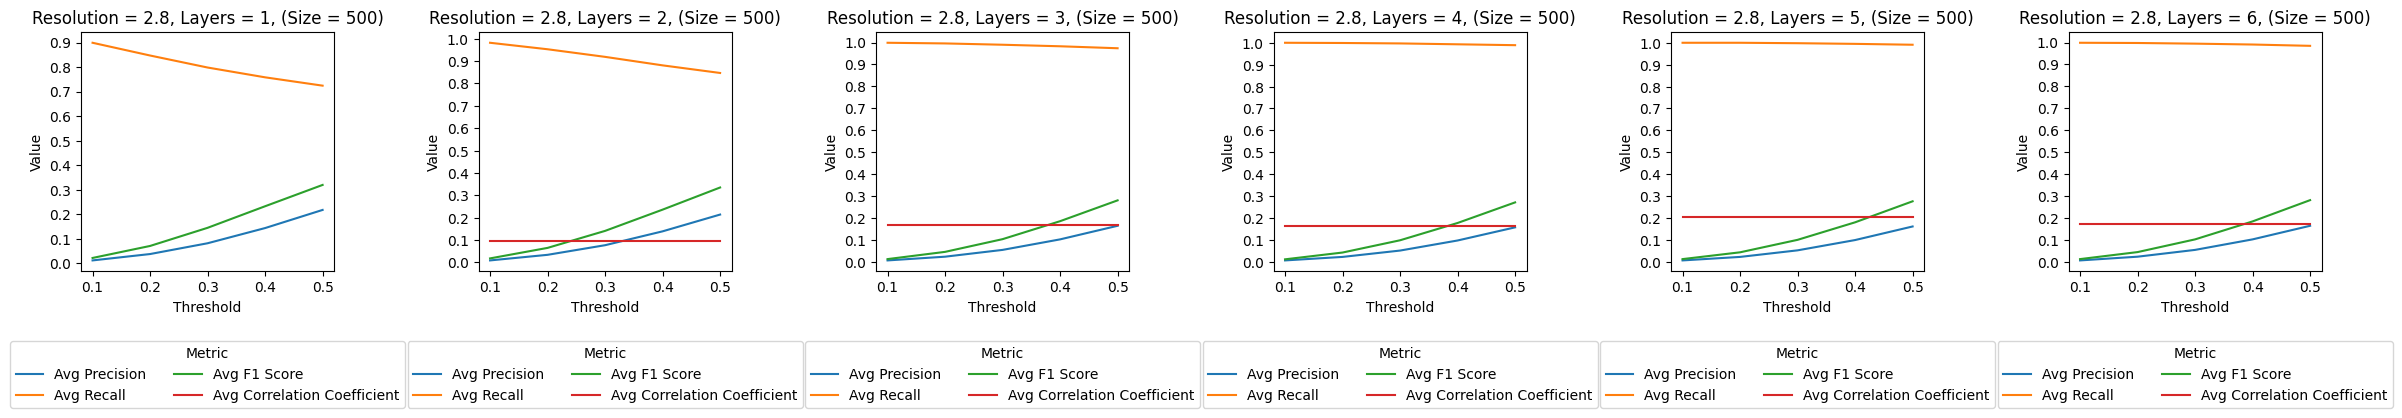

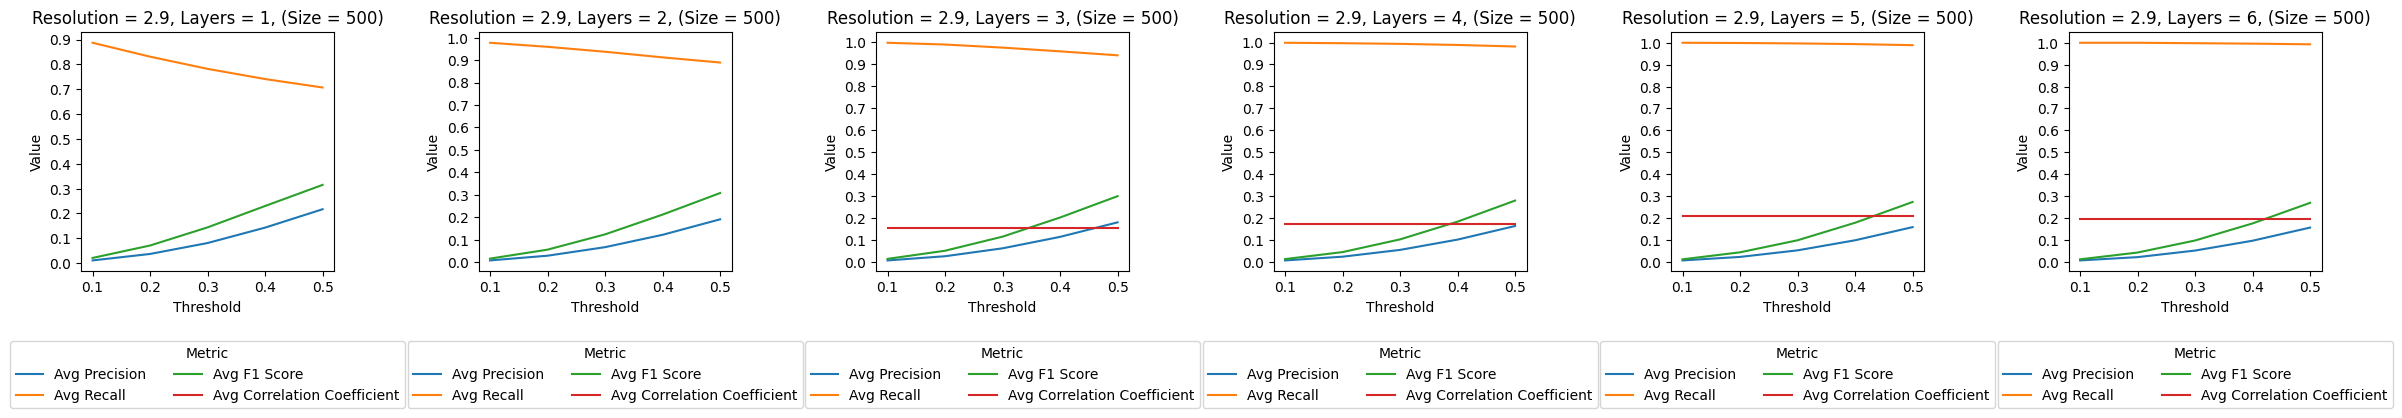

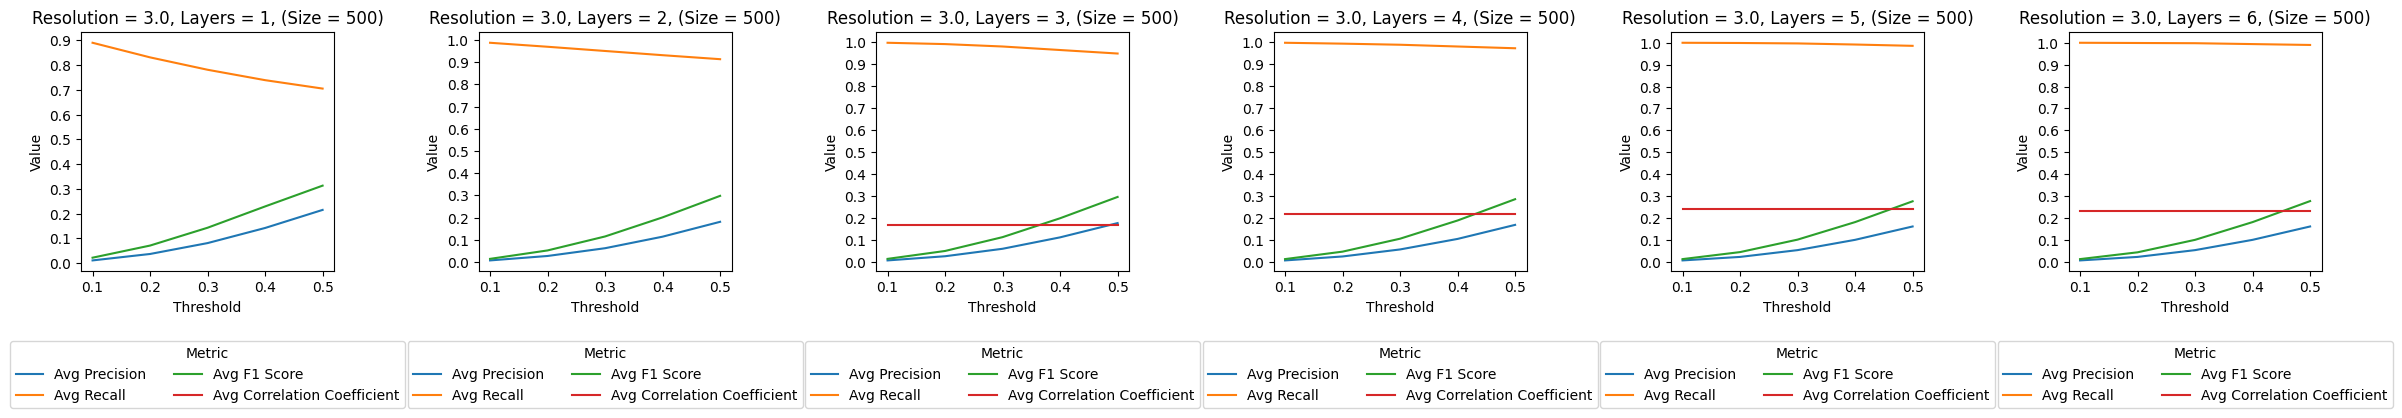

In [5]:
from matplotlib.ticker import MultipleLocator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get a sorted list of all Resolution values
resolutions = sorted(df["Resolution"].unique())

# For demonstration, assume "Size" is the same for all rows or you want just the first row's Size
size = df["Size"].iloc[0]

for res in resolutions:
    # 1) Subset the DataFrame for this Resolution
    df_res = df[df["Resolution"] == res]
    
    # 2) Melt so Precision, Recall, F1, and Correlation become a single column "metric"
    df_res_melted = df_res.melt(
        id_vars=["Layers", "Threshold"],    # columns NOT to melt
        value_vars=["Avg Precision", "Avg Recall", "Avg F1 Score", "Avg Correlation Coefficient"],
        var_name="metric",
        value_name="value"
    )
    
    # 3) Determine the distinct Layers in this subset
    layer_values = sorted(df_res_melted["Layers"].unique())
    num_layers = len(layer_values)
    
    # 4) Create a figure with one row and as many columns as there are Layers
    fig, axes = plt.subplots(nrows=1, ncols=num_layers,
                             figsize=(4 * num_layers, 4),
                             sharey=False)
    
    # If there is only one layer, axes is just an Axes object. Make it a list to simplify the loop.
    if num_layers == 1:
        axes = [axes]
    
    # 5) Loop over each layer and plot
    for i, layer_val in enumerate(layer_values):
        ax = axes[i]
        # Subset to the current layer
        subset_layer = df_res_melted[df_res_melted["Layers"] == layer_val]
        
        # Plot the metrics vs. Threshold, coloring by metric
        sns.lineplot(
            data=subset_layer,
            x="Threshold",
            y="value",
            hue="metric",
            ax=ax
        )
        
        ax.yaxis.set_major_locator(MultipleLocator(0.1))
        
        ax.legend(
            loc="lower center", 
            bbox_to_anchor=(0.5, -0.6),
            ncol=2, 
            title="Metric"
        )
        
        # Title, labels, etc.
        ax.set_title(f"Resolution = {res:.1f}, Layers = {layer_val}, (Size = {size})")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Value")
    
   
    fig.subplots_adjust(bottom=0.4)
    
    plt.tight_layout()
    plt.show()


# Helping with values 

In [ ]:
# # Read in csv file from rome-dtw-100
# df = pd.read_csv("results_true/similarity_values/rome/frechet/rome-frechet-300.csv", index_col=0)

# import pandas as pd
# import numpy as np


# # Convert all values to numeric, handling errors
# df = df.apply(pd.to_numeric, errors='coerce')

# # Define the target value and tolerance
# target_value = 0.001
# tolerance = 1e-3  # Adjust if necessary

# # Find intersections close to the target value
# matches = np.isclose(df.values, target_value, atol=tolerance)
# row_indices, col_indices = np.where(matches)

# #Find lowest value that is not zero
# min_value = df[df > 0].min().min()

# print(f"Lowest value that is not zero: {min_value}")

# # Get intersection details: row name, column name, and value
# intersections = [
#     (df.index[row], df.columns[col], df.iloc[row, col])
#     for row, col in zip(row_indices, col_indices)
# ]

# # Display intersection results with values
# if intersections:
#     for row_name, col_name, value in intersections:
#         print(f"Match at intersection of '{row_name}' and '{col_name}' with value: {value}")
# else:
#     print("No match found.")


